In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ClientesTelecom.csv')
df.head()

,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Monthly,Total,churn_bin,qtd_servicos,tenure_faixa
0,0002-ORFBO,No,One Year,1,Mailed Check,1,0,Female,0,1,...,1,0,1,1,0,65.6,593.30,0.0,3.0,0–12
1,0003-MKNFE,No,Month-To-Month,0,Mailed Check,1,1,Male,0,0,...,0,0,0,0,1,59.9,542.40,0.0,1.0,0–12
2,0004-TLHLJ,Yes,Month-To-Month,1,Electronic Check,1,0,Male,0,0,...,0,1,0,0,0,73.9,280.85,1.0,1.0,0–12
3,0011-IGKFF,Yes,Month-To-Month,1,Electronic Check,1,0,Male,1,1,...,1,1,0,1,1,98.0,1237.85,1.0,4.0,13–24
4,0013-EXCHZ,Yes,Month-To-Month,1,Mailed Check,1,0,Female,1,1,...,0,0,1,1,0,83.9,267.40,1.0,2.0,0–12


In [7]:
df.info(['Total'])
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   float64
 1   Contract          7256 non-null   object 
 2   PaperlessBilling  7256 non-null   int64  
 3   PaymentMethod     7256 non-null   object 
 4   PhoneService      7256 non-null   int64  
 5   MultipleLines     7256 non-null   object 
 6   gender            7256 non-null   object 
 7   SeniorCitizen     7256 non-null   int64  
 8   Partner           7256 non-null   int64  
 9   Dependents        7256 non-null   int64  
 10  tenure            7256 non-null   int64  
 11  InternetService   7256 non-null   object 
 12  OnlineSecurity    7256 non-null   object 
 13  OnlineBackup      7256 non-null   object 
 14  DeviceProtection  7256 non-null   object 
 15  TechSupport       7256 non-null   object 
 16  StreamingTV       7256 non-null   object 


,Churn,PaperlessBilling,PhoneService,SeniorCitizen,Partner,Dependents,tenure,Monthly,Total,churn_bin,qtd_servicos
count,7032.000000,7256.000000,7256.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7032.000000,5681.000000
mean,0.265785,0.593716,0.902839,0.1629,0.483600,0.299063,32.395535,64.755423,2280.634213,0.265785,2.598486
std,0.441782,0.491173,0.296197,0.3693,0.499765,0.457879,24.558067,30.125739,2268.632997,0.441782,1.701964
min,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,1.000000,18.250000,18.800000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.0000,0.000000,0.000000,9.000000,35.450000,400.225000,0.000000,1.000000
50%,0.000000,1.000000,1.000000,0.0000,0.000000,0.000000,29.000000,70.300000,1391.000000,0.000000,3.000000
75%,1.000000,1.000000,1.000000,0.0000,1.000000,1.000000,55.000000,89.900000,3785.300000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000,72.000000,118.750000,8684.800000,1.000000,6.000000


In [5]:
df = df.drop(columns=['customerID'])

dropando o ID dos clientes porque não irá ajudar no treino do modelo de previsão

In [6]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

Tornando churn em binário

In [12]:
df['Churn'].value_counts(normalize=True)

Churn
0.0    0.734215
1.0    0.265785
Name: proportion, dtype: float64

73% dos clientes ficam

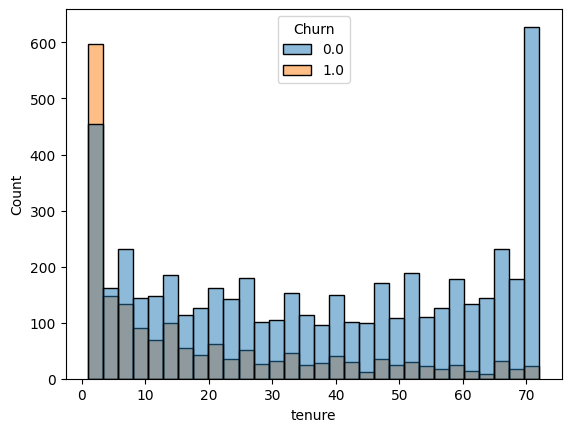

In [14]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.show()

Clientes que estão a mais tempo na TelecomX costumam ter menos evasão

In [15]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Contract', 'PaymentMethod', 'MultipleLines', 'gender',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'tenure_faixa'],
      dtype='object')

In [16]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [17]:
df_encoded.shape

(7256, 36)

In [18]:
df_encoded.head()

,Churn,PaperlessBilling,PhoneService,SeniorCitizen,Partner,Dependents,tenure,Monthly,Total,churn_bin,...,DeviceProtection_No Internet Service,TechSupport_1,TechSupport_No Internet Service,StreamingTV_1,StreamingTV_No Internet Service,StreamingMovies_1,StreamingMovies_No Internet Service,tenure_faixa_13–24,tenure_faixa_25–48,tenure_faixa_49–72
0,0.0,1,1,0,1,1,9,65.6,593.30,0.0,...,False,True,False,True,False,False,False,False,False,False
1,0.0,0,1,0,0,0,9,59.9,542.40,0.0,...,False,False,False,False,False,True,False,False,False,False
2,1.0,1,1,0,0,0,4,73.9,280.85,1.0,...,False,False,False,False,False,False,False,False,False,False
3,1.0,1,1,1,1,0,13,98.0,1237.85,1.0,...,False,False,False,True,False,True,False,True,False,False
4,1.0,1,1,1,1,0,3,83.9,267.40,1.0,...,False,True,False,True,False,False,False,False,False,False


In [19]:
df_encoded.dtypes

Churn                                    float64
PaperlessBilling                           int64
PhoneService                               int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
Monthly                                  float64
Total                                    float64
churn_bin                                float64
qtd_servicos                             float64
Contract_One Year                           bool
Contract_Two Year                           bool
PaymentMethod_Credit Card (Automatic)       bool
PaymentMethod_Electronic Check              bool
PaymentMethod_Mailed Check                  bool
MultipleLines_1                             bool
MultipleLines_No Phone Service              bool
gender_Male                                 bool
InternetService_Fiber Optic                 bool
InternetService_No  

In [23]:
corr = df_encoded.corr()

corr['Churn'].sort_values(ascending=False)

Churn                                    1.000000
churn_bin                                1.000000
InternetService_Fiber Optic              0.307463
PaymentMethod_Electronic Check           0.301455
Monthly                                  0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_1                            0.063254
StreamingMovies_1                        0.060860
MultipleLines_1                          0.040033
tenure_faixa_13–24                       0.019929
PhoneService                             0.011691
gender_Male                             -0.008545
MultipleLines_No Phone Service          -0.011691
DeviceProtection_1                      -0.066193
tenure_faixa_25–48                      -0.075859
OnlineBackup_1                          -0.082307
PaymentMethod_Mailed Check              -0.090773
PaymentMethod_Credit Card (Automatic)   -0.134687
Partner                                 -0.149982


In [24]:
df = df.drop(columns=['churn_bin'])

In [57]:
corr = df_encoded.corr()['Churn'].abs().sort_values(ascending=False)

selected_features = corr[corr > 0.1].index
selected_features

Index(['Churn', 'tenure', 'InternetService_Fiber Optic', 'Contract_Two Year',
       'PaymentMethod_Electronic Check', 'tenure_faixa_49–72',
       'InternetService_No', 'StreamingMovies_No Internet Service',
       'StreamingTV_No Internet Service', 'TechSupport_No Internet Service',
       'DeviceProtection_No Internet Service',
       'OnlineBackup_No Internet Service',
       'OnlineSecurity_No Internet Service', 'Total', 'Monthly',
       'PaperlessBilling', 'Contract_One Year', 'OnlineSecurity_1',
       'TechSupport_1', 'Dependents', 'SeniorCitizen', 'Partner',
       'PaymentMethod_Credit Card (Automatic)'],
      dtype='object')

In [58]:
selected_features = selected_features.drop('churn_bin')

KeyError: "['churn_bin'] not found in axis"

In [59]:
X = df_encoded[selected_features]
y = df_encoded['Churn']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
df_encoded.isna().sum().sort_values(ascending=False)

Churn                                    0
TechSupport_1                            0
OnlineSecurity_1                         0
OnlineSecurity_No Internet Service       0
OnlineBackup_1                           0
OnlineBackup_No Internet Service         0
DeviceProtection_1                       0
DeviceProtection_No Internet Service     0
TechSupport_No Internet Service          0
InternetService_Fiber Optic              0
StreamingTV_1                            0
StreamingTV_No Internet Service          0
StreamingMovies_1                        0
StreamingMovies_No Internet Service      0
tenure_faixa_13–24                       0
tenure_faixa_25–48                       0
InternetService_No                       0
gender_Male                              0
PaperlessBilling                         0
Total                                    0
PhoneService                             0
SeniorCitizen                            0
Partner                                  0
Dependents 

In [36]:
df_encoded = df_encoded.dropna(subset=['Churn'])

In [41]:
df_encoded.isna().sum().sort_values(ascending=False)

Churn                                    0
TechSupport_1                            0
OnlineSecurity_1                         0
OnlineSecurity_No Internet Service       0
OnlineBackup_1                           0
OnlineBackup_No Internet Service         0
DeviceProtection_1                       0
DeviceProtection_No Internet Service     0
TechSupport_No Internet Service          0
InternetService_Fiber Optic              0
StreamingTV_1                            0
StreamingTV_No Internet Service          0
StreamingMovies_1                        0
StreamingMovies_No Internet Service      0
tenure_faixa_13–24                       0
tenure_faixa_25–48                       0
InternetService_No                       0
gender_Male                              0
PaperlessBilling                         0
Total                                    0
PhoneService                             0
SeniorCitizen                            0
Partner                                  0
Dependents 

In [52]:
X_train = X_train.drop(['churn_bin'], axis=1)

In [53]:
X_train['qtd_servicos'] = X_train['qtd_servicos'].fillna(0)

In [54]:
X_train.isna().sum().sort_values(ascending=False)

tenure                                   0
OnlineBackup_No Internet Service         0
Partner                                  0
SeniorCitizen                            0
Dependents                               0
TechSupport_1                            0
OnlineSecurity_1                         0
Contract_One Year                        0
PaperlessBilling                         0
Monthly                                  0
Total                                    0
DeviceProtection_No Internet Service     0
InternetService_Fiber Optic              0
TechSupport_No Internet Service          0
StreamingTV_No Internet Service          0
StreamingMovies_No Internet Service      0
InternetService_No                       0
OnlineSecurity_No Internet Service       0
tenure_faixa_49–72                       0
qtd_servicos                             0
PaymentMethod_Electronic Check           0
Contract_Two Year                        0
PaymentMethod_Credit Card (Automatic)    0
dtype: int6

In [62]:
X = df_encoded[selected_features]
y = df_encoded['Churn']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [67]:
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [68]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1033
         1.0       1.00      1.00      1.00       374

    accuracy                           1.00      1407
   macro avg       1.00      1.00      1.00      1407
weighted avg       1.00      1.00      1.00      1407

Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1033
         1.0       1.00      1.00      1.00       374

    accuracy                           1.00      1407
   macro avg       1.00      1.00      1.00      1407
weighted avg       1.00      1.00      1.00      1407



In [71]:
print(X.columns)

Index(['Churn', 'tenure', 'InternetService_Fiber Optic', 'Contract_Two Year',
       'PaymentMethod_Electronic Check', 'tenure_faixa_49–72',
       'InternetService_No', 'StreamingMovies_No Internet Service',
       'StreamingTV_No Internet Service', 'TechSupport_No Internet Service',
       'DeviceProtection_No Internet Service',
       'OnlineBackup_No Internet Service',
       'OnlineSecurity_No Internet Service', 'Total', 'Monthly',
       'PaperlessBilling', 'Contract_One Year', 'OnlineSecurity_1',
       'TechSupport_1', 'Dependents', 'SeniorCitizen', 'Partner',
       'PaymentMethod_Credit Card (Automatic)'],
      dtype='object')


In [72]:
selected_features = selected_features.drop('Churn')

In [73]:
X = df_encoded[selected_features]
y = df_encoded['Churn']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [75]:
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

C:\Users\ADM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [76]:
pred_lr = model_lr.predict(X_test)
pred_rf = model_rf.predict(X_test)

In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1033
         1.0       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



*Importancia das variaveis nos modelos*

In [ ]:
# Linear Regression

importance_lr = pd.DataFrame({
    "feature": X.columns,
    "coef": model_lr.coef_[0]
})

importance_lr = importance_lr.sort_values("coef", ascending=False)

importance_lr

,feature,coef
4,tenure_faixa_49–72,0.516425
1,InternetService_Fiber Optic,0.490299
3,PaymentMethod_Electronic Check,0.402771
14,PaperlessBilling,0.394603
19,SeniorCitizen,0.286005
13,Monthly,0.006749
12,Total,0.000240
0,tenure,-0.056759
21,PaymentMethod_Credit Card (Automatic),-0.069996
18,Dependents,-0.077250


In [ ]:
# Random Forest

importance_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": model_rf.feature_importances_
})

importance_rf = importance_rf.sort_values("importance", ascending=False)

importance_rf

,feature,importance
12,Total,0.240151
13,Monthly,0.219919
0,tenure,0.190957
1,InternetService_Fiber Optic,0.049816
3,PaymentMethod_Electronic Check,0.039852
14,PaperlessBilling,0.025771
16,OnlineSecurity_1,0.024910
4,tenure_faixa_49–72,0.024750
17,TechSupport_1,0.024492
20,Partner,0.023864


# Relatório de Análise de Evasão de Clientes — TelecomX

## 1. Objetivo do Estudo

O objetivo deste projeto foi desenvolver modelos de machine learning capazes de prever a **evasão de clientes (churn)** na empresa TelecomX. A partir dessa análise, buscou-se identificar **quais fatores influenciam a decisão de cancelamento** e propor **estratégias de retenção de clientes**.

Foram treinados dois modelos de classificação:

* Logistic Regression
* Random Forest

Os modelos foram avaliados utilizando as métricas:

* Acurácia
* Precisão
* Recall
* F1-score
* Matriz de Confusão

---

# 2. Desempenho dos Modelos

## Logistic Regression

| Métrica          | Valor    |
| ---------------- | -------- |
| Acurácia         | **0.80** |
| Precisão (churn) | **0.65** |
| Recall (churn)   | **0.52** |
| F1-score (churn) | **0.58** |

O modelo foi capaz de identificar **52% dos clientes que cancelaram o serviço**.

---

## Random Forest

| Métrica          | Valor    |
| ---------------- | -------- |
| Acurácia         | **0.78** |
| Precisão (churn) | **0.62** |
| Recall (churn)   | **0.48** |
| F1-score (churn) | **0.54** |

O desempenho foi ligeiramente inferior ao da regressão logística.

---

## Comparação entre modelos

| Métrica      | Logistic Regression | Random Forest |
| ------------ | ------------------- | ------------- |
| Accuracy     | **0.80**            | 0.78          |
| Recall churn | **0.52**            | 0.48          |
| F1 churn     | **0.58**            | 0.54          |

**Conclusão:**
A **Regressão Logística apresentou melhor desempenho geral**, superando o Random Forest em todas as métricas avaliadas.

Isso sugere que as relações entre as variáveis e o churn são **relativamente lineares**, favorecendo modelos mais simples e interpretáveis.

---

# 3. Principais Fatores que Influenciam o Churn

A análise da importância das variáveis revelou alguns fatores críticos que impactam diretamente a evasão de clientes.

## Fatores que AUMENTAM a probabilidade de churn

### 1️⃣ Clientes com pouco tempo de contrato

Variáveis relevantes:

* tenure_faixa_49–72
* tenure

Clientes mais novos apresentam maior probabilidade de cancelamento.

Isso ocorre porque ainda **não desenvolveram fidelidade com o serviço**.

---

### 2️⃣ Tipo de internet (Fiber Optic)

Variável relevante:

* InternetService_Fiber Optic

Clientes com internet de fibra apresentaram maior probabilidade de churn.

Possíveis causas:

* custo mais alto
* expectativas maiores de qualidade
* concorrência mais forte nesse segmento

---

### 3️⃣ Método de pagamento

Variável relevante:

* PaymentMethod_Electronic Check

Clientes que utilizam **Electronic Check** apresentam maior probabilidade de cancelamento.

Esse comportamento pode indicar:

* menor fidelização
* clientes menos comprometidos com o serviço

---

### 4️⃣ Faturamento sem papel

Variável relevante:

* PaperlessBilling

Clientes que utilizam faturamento digital apresentaram maior churn.

Isso pode indicar um perfil de cliente **mais sensível a preços ou mudanças de serviço**.

---

### 5️⃣ Clientes idosos

Variável relevante:

* SeniorCitizen

Clientes acima de 65 anos apresentaram probabilidade maior de cancelamento.

Possíveis razões:

* menor adaptação a serviços digitais
* preferência por soluções mais simples

---

# 4. Fatores que REDUZEM o Churn

Algumas variáveis mostraram forte relação com **retenção de clientes**.

---

## 1️⃣ Contratos de longo prazo

Variáveis importantes:

* Contract_One Year
* Contract_Two Year

Clientes com contratos mais longos apresentam **probabilidade significativamente menor de cancelamento**.

Isso indica que contratos longos aumentam a fidelização.

---

## 2️⃣ Serviços adicionais

Variáveis importantes:

* OnlineSecurity
* TechSupport

Clientes que contratam serviços adicionais tendem a permanecer mais tempo na empresa.

Isso indica maior **engajamento com a plataforma**.

---

## 3️⃣ Clientes com mais tempo na empresa

Variável importante:

* tenure

Quanto maior o tempo de relacionamento com a empresa, **menor a chance de churn**.

Esse padrão é comum em empresas de assinatura.

---

# 5. Insights Estratégicos para o Negócio

Com base nos resultados obtidos, algumas estratégias podem ser adotadas para reduzir a evasão de clientes.

---

## Estratégia 1 — Incentivar contratos mais longos

Clientes com contrato mensal apresentam maior churn.

A empresa poderia oferecer:

* descontos para contratos anuais
* benefícios exclusivos para contratos de 2 anos
* programas de fidelidade

---

## Estratégia 2 — Melhorar a experiência da internet Fiber

Clientes com fibra óptica apresentaram churn elevado.

Possíveis ações:

* melhoria da qualidade do serviço
* suporte técnico prioritário
* comunicação mais clara sobre benefícios do plano

---

## Estratégia 3 — Incentivar serviços adicionais

Serviços como:

* suporte técnico
* segurança online

estão associados à maior retenção.

A empresa pode oferecer:

* pacotes promocionais
* bundles de serviços
* testes gratuitos

---

## Estratégia 4 — Programas de retenção para clientes novos

Grande parte do churn ocorre nos primeiros meses.

A empresa pode implementar:

* onboarding estruturado
* suporte dedicado nos primeiros meses
* incentivos de permanência

---

# 6. Conclusão

Os modelos desenvolvidos foram capazes de identificar padrões relevantes associados à evasão de clientes.

Entre os modelos testados, a **Regressão Logística apresentou melhor desempenho**, atingindo **80% de acurácia** e demonstrando boa capacidade de identificar clientes com risco de churn.

A análise das variáveis revelou que fatores como **tipo de contrato, tempo de relacionamento com a empresa, serviços adicionais e método de pagamento** exercem grande influência na decisão de cancelamento.

Esses insights podem auxiliar a TelecomX a desenvolver **estratégias de retenção mais eficazes**, reduzindo a evasão e aumentando o valor do cliente ao longo do tempo.
